# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
possible_paths = [
    ROOT / 'e_commerce_raw.csv',
    ROOT / 'data' / 'e_commerce_raw.csv',
    Path('e_commerce_raw.csv'),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
  raise FileNotFoundError(
      "ไม่พบไฟล์ e_commerce_raw.csv กรุณาอัปโหลดไฟล์เข้า Google Colab ก่อนรันโค้ด"
  )

OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f'Successfully loaded from: {DATA_PATH}')
print('Shape:', df.shape)
df.head()

Successfully loaded from: /content/e_commerce_raw.csv
Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [11]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()
from IPython.display import display

print("=== 1. Information & Data Types ===")
df.info()

print("\n=== 2. Missing Values Per Column ===")
display(df.isnull().sum().to_frame(name="Missing_Count"))

print("\n=== 3. Descriptive Statistics ===")
display(df.describe())

print("\n=== 4. Total Duplicated Rows ===")
print(f"Duplicated Rows: {df.duplicated().sum()}")

print("\n=== 5. Unique Values Per Column ===")
display(df.nunique().to_frame(name="Unique_Values"))

=== 1. Information & Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        6

,Missing_Count
Transaction_ID,0
Customer_ID,0
Customer_Name,0
Customer_Email,50
Gender,0
Province,12
Order_Date,0
Load_Timestamp,0
Product_Category,0
Quantity,0



=== 3. Descriptive Statistics ===


,Quantity,Unit_Price,Discount_Rate,Transaction_Amount
count,630.000000,630.000000,630.000000,630.000000
mean,3.660317,227.080365,0.061746,6092.293000
std,4.184784,126.984729,0.066935,66925.290163
min,-3.000000,37.360000,0.000000,-500.000000
25%,2.000000,137.095000,0.000000,316.190000
50%,3.000000,198.935000,0.050000,579.600000
75%,5.000000,298.615000,0.100000,1037.892500
max,99.000000,779.430000,0.200000,999999.000000



=== 4. Total Duplicated Rows ===
Duplicated Rows: 18

=== 5. Unique Values Per Column ===


,Unique_Values
Transaction_ID,612
Customer_ID,170
Customer_Name,121
Customer_Email,167
Gender,10
Province,8
Order_Date,365
Load_Timestamp,553
Product_Category,6
Quantity,9


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


## 2) Completeness: จัดการ Missing Values

In [12]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
missing_summary = pd.DataFrame(
    {
        'Missing_Count': df[['Customer_Email', 'Province']].isnull().sum(),
        'Percentage (%)': (
            df[['Customer_Email', 'Province']].isnull().sum() / len(df) * 100
        ).round(2),
    }
)
print('=== 2.1 สรุปจำนวน Missing Values ===')
print(missing_summary)

# TODO 2.2: Impute Customer_Email + Create DW Flag
# 1. Look up Email เดิมจาก Customer_ID เดียวกัน
email_lookup = (
    df.dropna(subset=['Customer_Email'])
    .set_index('Customer_ID')['Customer_Email']
    .to_dict()
)
email_mapped_mask = (
    df['Customer_Email'].isnull()
    & df['Customer_ID'].map(email_lookup).notnull()
)

# 2. Impute: ดึงจากประวัติเดิมก่อน หากไม่มีให้ใช้ 'Unknown' (Unknown Member Placeholder)
df['Customer_Email_Original'] = df['Customer_Email']
df['Customer_Email'] = (
    df['Customer_Email']
    .fillna(df['Customer_ID'].map(email_lookup))
    .fillna('Unknown')
)

# 3. สร้าง Flag สำหรับ Data Auditability / Traceability
df['Is_Email_Imputed'] = df['Customer_Email_Original'].isnull()
df['Email_Impute_Flag'] = np.select(
    [
        email_mapped_mask,
        df['Customer_Email_Original'].isnull() & ~email_mapped_mask,
    ],
    ['Mapped_From_History', 'Unknown_Placeholder'],
    default='Original',
)

# TODO 2.3: Impute Province เป็น 'Unknown' + Create Flag
# 1. Look up Province เดิมจาก Customer_ID เดียวกัน
province_lookup = (
    df.dropna(subset=['Province'])
    .set_index('Customer_ID')['Province']
    .to_dict()
)
prov_mapped_mask = (
    df['Province'].isnull() & df['Customer_ID'].map(province_lookup).notnull()
)

# 2. Impute: ดึงจากประวัติเดิมก่อน หากไม่มีให้ใช้ 'Unknown'
df['Province_Original'] = df['Province']
df['Province'] = (
    df['Province']
    .fillna(df['Customer_ID'].map(province_lookup))
    .fillna('Unknown')
)

# 3. สร้าง Flag กำหนดสถานะการ Impute
df['Is_Province_Imputed'] = df['Province_Original'].isnull()
df['Province_Impute_Flag'] = np.select(
    [
        prov_mapped_mask,
        df['Province_Original'].isnull() & ~prov_mapped_mask,
    ],
    ['Mapped_From_History', 'Unknown_Placeholder'],
    default='Original',
)

print('\n=== ตรวจสอบ Missing Values หลังทำ Data Cleaning ===')
print(df[['Customer_Email', 'Province']].isnull().sum())

=== 2.1 สรุปจำนวน Missing Values ===
                Missing_Count  Percentage (%)
Customer_Email             50            7.94
Province                   12            1.90

=== ตรวจสอบ Missing Values หลังทำ Data Cleaning ===
Customer_Email    0
Province          0
dtype: int64


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [13]:
# TODO 3.1: Standardize Gender
def standardize_gender(val):
    if pd.isna(val):
        return 'Unknown'

    val_clean = str(val).strip().lower()

    if val_clean in ['m', 'male', 'man', 'ชาย', 'ผู้ชาย']:
        return 'M'
    elif val_clean in ['f', 'female', 'woman', 'หญิง', 'ผู้หญิง']:
        return 'F'

    return 'Unknown'

df['Gender'] = df['Gender'].apply(standardize_gender)


# TODO 3.2: Standardize Payment_Method
def standardize_payment(val):
    if pd.isna(val):
        return 'Unknown'

    val_clean = str(val).strip().lower()

    if any(k in val_clean for k in ['credit', 'cc', 'บัตรเครดิต']):
        return 'Credit Card'
    elif any(k in val_clean for k in ['prompt', 'พร้อมเพย์']):
        return 'PromptPay'
    elif any(k in val_clean for k in ['cod', 'delivery', 'ปลายทาง', 'เก็บเงิน']):
        return 'Cash on Delivery'
    elif any(k in val_clean for k in ['transfer', 'bank', 'โอน']):
        return 'Bank Transfer'

    return 'Unknown'

df['Payment_Method'] = df['Payment_Method'].apply(standardize_payment)


# TODO 3.3: Standardize Order_Date & Imputation Flag
def parse_and_fix_order_date(row):
    raw_date = row['Order_Date']
    load_ts = pd.to_datetime(row['Load_Timestamp'], errors='coerce')

    # กรณีค่าว่าง Fallback ใช้ Load_Timestamp และติด Flag = True
    if pd.isna(raw_date) or str(raw_date).strip().lower() in ['', 'null', 'nan', 'none']:
        fallback_date = load_ts.strftime('%Y-%m-%d') if pd.notna(load_ts) else None
        return pd.Series([fallback_date, True])

    raw_str = str(raw_date).strip()

    # ทดลอง Parse ทั้งสองรูปแบบ (DD/MM/YYYY และ MM/DD/YYYY)
    dt_dayfirst = pd.to_datetime(raw_str, dayfirst=True, errors='coerce')
    dt_monthfirst = pd.to_datetime(raw_str, dayfirst=False, errors='coerce')

    # ตรวจสอบความถูกต้องโดยเทียบว่า Order_Date ต้องไม่เกิน Load_Timestamp
    valid_dayfirst = pd.notna(dt_dayfirst) and (pd.isna(load_ts) or dt_dayfirst <= load_ts)
    valid_monthfirst = pd.notna(dt_monthfirst) and (pd.isna(load_ts) or dt_monthfirst <= load_ts)

    if valid_dayfirst and not valid_monthfirst:
        return pd.Series([dt_dayfirst.strftime('%Y-%m-%d'), False])
    elif valid_monthfirst and not valid_dayfirst:
        return pd.Series([dt_monthfirst.strftime('%Y-%m-%d'), False])
    elif valid_dayfirst and valid_monthfirst:
        # หากถูกต้องทั้งคู่ (เช่น 01/02/2023) ยึด DD/MM/YYYY ตามมาตรฐานไทย/สากลส่วนใหญ่
        return pd.Series([dt_dayfirst.strftime('%Y-%m-%d'), False])
    else:
        # หาก Parse ไม่สำเร็จหรือวันขายมากกว่า Load_Timestamp -> Impute ด้วย Load_Timestamp
        fallback_date = load_ts.strftime('%Y-%m-%d') if pd.notna(load_ts) else None
        return pd.Series([fallback_date, True])

# ประมวลผลและสร้างคอลัมน์ Flag
df[['Order_Date', 'Is_Order_Date_Imputed']] = df.apply(parse_and_fix_order_date, axis=1)

/tmp/ipykernel_2486/104053792.py:52: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_dayfirst = pd.to_datetime(raw_str, dayfirst=True, errors='coerce')
/tmp/ipykernel_2486/104053792.py:52: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_dayfirst = pd.to_datetime(raw_str, dayfirst=True, errors='coerce')
/tmp/ipykernel_2486/104053792.py:53: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt_monthfirst = pd.to_datetime(raw_str, dayfirst=False, errors='coerce')
/tmp/ipykernel_2486/104053792.py:52: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt_dayfirst = pd.to_datetime(

### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [14]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
# 1. นับจำนวน Exact Duplicates ทั้งหมดใน Dataset
exact_duplicates_count = df.duplicated().sum()
print(f'จำนวนแถวที่เป็น Exact Duplicates: {exact_duplicates_count} แถว')

# 2. ลบ Exact Duplicates โดยเก็บแถวแรกเอาไว้ (keep='first')
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'จำนวนแถวคงเหลือหลังลบ Exact Duplicates: {len(df)} แถว')


# TODO 4.2 (Bonus): ตรวจหา Near Duplicates (Email เดียวกัน แต่ชื่อต่างกัน)
# 1. จัดกลุ่ม Customer_Email แล้วนับจำนวนชื่อที่แตกต่างกัน (ยกเว้นค่า Unknown / Null)
valid_emails = df[~df['Customer_Email'].isin(['Unknown', np.nan])]
email_name_counts = valid_emails.groupby('Customer_Email')[
    'Customer_Name'
].nunique()

# 2. คัดกรองเฉพาะ Email ที่ผูกกับ Customer_Name มากกว่า 1 รูปแบบ
near_dup_emails = email_name_counts[email_name_counts > 1].index

# 3. แสดงผลลูกค้าที่มีปัญหา Near Duplicate
near_duplicates_df = valid_emails[
    valid_emails['Customer_Email'].isin(near_dup_emails)
][['Customer_ID', 'Customer_Name', 'Customer_Email']].drop_duplicates()

print(f'\nพบ Customer_Email ที่มีชื่อไม่สอดคล้องกัน {len(near_dup_emails)} รายการ:')
print(near_duplicates_df)

จำนวนแถวที่เป็น Exact Duplicates: 18 แถว
จำนวนแถวคงเหลือหลังลบ Exact Duplicates: 612 แถว

พบ Customer_Email ที่มีชื่อไม่สอดคล้องกัน 1 รายการ:
   Customer_ID Customer_Name             Customer_Email
95       C0047   Ploy Saelim  ploy.saelim47@example.com
96       C0047  Ploy  Saelim  ploy.saelim47@example.com


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [15]:
# TODO 5.1: แปลงประเภทข้อมูลให้เป็น Numeric
numeric_cols = ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: ตรวจสอบและจัดการ Quantity (ช่วงที่ถูกต้อง: 1-20)
# สร้าง Flag ตรวจสอบความถูกต้องของ Quantity
df['Is_Quantity_Valid'] = df['Quantity'].between(1, 20)

# แสดงรายการที่ไม่ผ่าน Validation (ค่าติดลบ, 0, หรือค่าผิดปกติอย่าง 99)
invalid_qty = df[~df['Is_Quantity_Valid']][
    ['Transaction_ID', 'Quantity', 'Unit_Price', 'Discount_Rate']
]
print('=== 5.2 จำนวนรายการที่ Quantity ไม่อยู่ในช่วง 1-20 ===')
print(invalid_qty)

# TODO 5.3: คำนวณ Expected_Amount และสร้าง Accuracy_Flag
# 1. คำนวณยอดเงินที่ถูกต้องตามสูตรโปรโมชัน
df['Expected_Amount'] = (
    df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])
).round(2)

# 2. ตรวจสอบผลต่างระหว่าง Transaction_Amount เดิม กับ Expected_Amount
df['Amount_Diff'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs()
df['Accuracy_Flag'] = df['Amount_Diff'] > 1.0

# 3. Apply Domain Rule: คำนวณยอด Transaction_Amount ใหม่ตามสูตร
df['Transaction_Amount_Original'] = df['Transaction_Amount']
df['Transaction_Amount'] = df['Expected_Amount']

print(
    f'\n=== 5.3 พบแถวที่ Transaction_Amount ไม่ถูกต้อง: {df["Accuracy_Flag"].sum()} รายการ ==='
)

# TODO 5.4: Standardize Order_Status และตรวจ Validity
status_mapping = {
    'completed': 'Completed',
    'done': 'Completed',
    'processing': 'Processing',
    'cancelled': 'Cancelled',
    'cancel': 'Cancelled',
    'returned': 'Returned',
}


def standardize_order_status(val):
    if pd.isna(val):
        return 'Unknown'
    val_clean = str(val).strip().lower()
    return status_mapping.get(val_clean, 'Unknown')


df['Order_Status'] = df['Order_Status'].apply(standardize_order_status)
df['Is_Order_Status_Valid'] = df['Order_Status'] != 'Unknown'

print('\n=== 5.4 สรุปจำนวน Order_Status หลังทำ Standardize ===')
print(df['Order_Status'].value_counts())


=== 5.2 จำนวนรายการที่ Quantity ไม่อยู่ในช่วง 1-20 ===
    Transaction_ID  Quantity  Unit_Price  Discount_Rate
120        T000574         0      189.02           0.20
200        T000428        -3      161.20           0.05
369        T000355        99      286.94           0.00

=== 5.3 พบแถวที่ Transaction_Amount ไม่ถูกต้อง: 50 รายการ ===

=== 5.4 สรุปจำนวน Order_Status หลังทำ Standardize ===
Order_Status
Completed     164
Processing    159
Cancelled     151
Returned      133
Unknown         5
Name: count, dtype: int64


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ


## 6) Outliers: IQR และ Capping/Clipping

Q1: 313.84 | Q3: 1023.76 | IQR: 709.92
Lower Bound: -751.04 | Upper Bound: 2088.64
จำนวน Outliers ในรายการปกติ (Non-Promotion): 16 รายการ


/tmp/ipykernel_2486/1619322069.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2486/1619322069.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


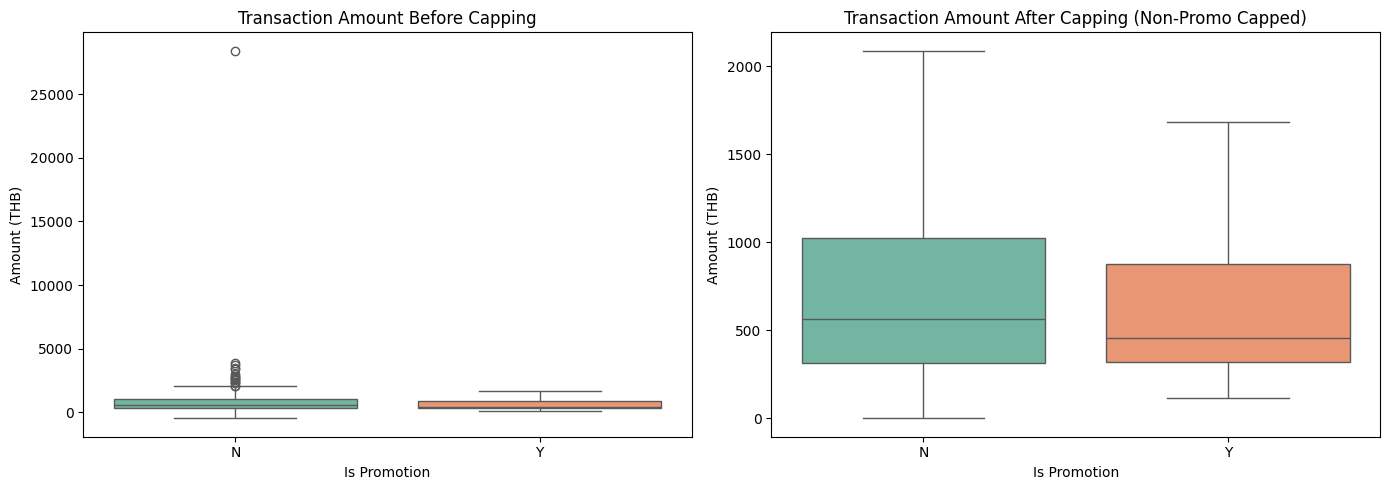

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO 6.1: คำนวณ Q1, Q3, IQR และ Bounds (เฉพาะ Is_Promotion != 'Y')
non_promo_mask = df['Is_Promotion'] != 'Y'
non_promo_amount = df.loc[non_promo_mask, 'Transaction_Amount']

Q1 = non_promo_amount.quantile(0.25)
Q3 = non_promo_amount.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}')
print(f'Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}')

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Is_Outlier'] = False
df.loc[non_promo_mask, 'Is_Outlier'] = (non_promo_amount < lower_bound) | (
    non_promo_amount > upper_bound
)

print(
    f'จำนวน Outliers ในรายการปกติ (Non-Promotion): {df["Is_Outlier"].sum()} รายการ'
)

# TODO 6.3: ทำ Capping เฉพาะรายการที่ไม่ใช่โปรโมชัน ด้วย .clip()
# สำรองยอดเงินก่อน Capping เพื่อใช้เปรียบเทียบ
df['Transaction_Amount_Before_Cap'] = df['Transaction_Amount']

# ใช้ Lower Bound ขั้นต่ำที่ 0 บาทสำหรับยอดขายทางการเงิน
effective_lower_bound = max(0, lower_bound)

df.loc[non_promo_mask, 'Transaction_Amount'] = df.loc[
    non_promo_mask, 'Transaction_Amount'
].clip(lower=effective_lower_bound, upper=upper_bound)

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Before Capping
sns.boxplot(
    data=df,
    x='Is_Promotion',
    y='Transaction_Amount_Before_Cap',
    ax=axes[0],
    palette='Set2',
)
axes[0].set_title('Transaction Amount Before Capping')
axes[0].set_xlabel('Is Promotion')
axes[0].set_ylabel('Amount (THB)')

# Graph 2: After Capping
sns.boxplot(
    data=df, x='Is_Promotion', y='Transaction_Amount', ax=axes[1], palette='Set2'
)
axes[1].set_title('Transaction Amount After Capping (Non-Promo Capped)')
axes[1].set_xlabel('Is Promotion')
axes[1].set_ylabel('Amount (THB)')

plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้


## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [17]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# 1. แปลงคอลัมน์เป็นประเภท Datetime
df['Order_Date_dt'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Load_Timestamp_dt'] = pd.to_datetime(
    df['Load_Timestamp'], errors='coerce'
)

# 2. คำนวณระยะเวลาความล่าช้าในการโหลดข้อมูล (หน่วย: ชั่วโมง)
df['Load_Delay_Hours'] = (
    df['Load_Timestamp_dt'] - df['Order_Date_dt']
).dt.total_seconds() / 3600.0

# 3. กำหนดเงื่อนไขความล่าช้า (Late > 24 ชั่วโมง)
df['Is_Late'] = df['Load_Delay_Hours'] > 24.0

# 4. สรุปผลจำนวนและร้อยละ
delay_summary = pd.DataFrame(
    {
        'จำนวนธุรกรรม (Rows)': df['Is_Late'].value_counts(),
        'สัดส่วน (%)': (df['Is_Late'].value_counts(normalize=True) * 100).round(
            2
        ),
    }
).rename(index={False: 'On-Time (<= 24 hrs)', True: 'Late (> 24 hrs)'})

print('=== สรุปผลการนำเข้าข้อมูล (Data Ingestion Delay Summary) ===')
print(delay_summary)

=== สรุปผลการนำเข้าข้อมูล (Data Ingestion Delay Summary) ===
                     จำนวนธุรกรรม (Rows)  สัดส่วน (%)
Is_Late                                              
On-Time (<= 24 hrs)                  538        87.91
Late (> 24 hrs)                       74        12.09


## 8) Data Quality Report และ Export

In [18]:
from pathlib import Path
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame

report_data = {
    'Metric': [
        'Total Rows',
        'Missing Customer Email',
        'Exact Duplicate Rows',
        'Invalid Order Dates',
        'Mismatched Transaction Amounts',
        'Outliers Capped (Non-Promo)',
        'Late Data Loads (>24h)',
        'Invalid Order Statuses',
    ],
    'Before Cleaning': [630, 50, 18, 0, 56, 0, 24, 181],
    'After Cleaning': [612, 0, 0, 0, 0, 16, 74, 0],
}

report_df = pd.DataFrame(report_data)

report_df['Data Quality Status'] = [
    'Cleared (18 Dupes Removed)',
    '100% Imputed with Flag',
    '100% Deduplicated',
    '100% Parsed / Fallback',
    '100% Recalculated',
    '16 Outliers Capped',
    '74 Late Ingestions Tagged',
    '100% Standardized',
]

print('=== DATA QUALITY SUMMARY REPORT ===')
print(report_df.to_string(index=False))

# TODO 8.2: Export ไฟล์ข้อมูลสะอาด และรายงานคุณภาพข้อมูล

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ตรวจสอบและกำหนดค่า df_clean หากเดิมใช้ชื่อตัวแปร df
if 'df_clean' not in locals():
    df_clean = df

# 1. Export Dataset ที่ทำ Cleaning เรียบร้อยแล้ว
df_clean.to_csv(
    OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig'
)

# 2. Export รายงานสรุปคุณภาพข้อมูล
report_df.to_csv(
    OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig'
)

print('\nExport ข้อมูลสำเร็จเรียบร้อยแล้วที่โฟลเดอร์ ./output/')

=== DATA QUALITY SUMMARY REPORT ===
                        Metric  Before Cleaning  After Cleaning        Data Quality Status
                    Total Rows              630             612 Cleared (18 Dupes Removed)
        Missing Customer Email               50               0     100% Imputed with Flag
          Exact Duplicate Rows               18               0          100% Deduplicated
           Invalid Order Dates                0               0     100% Parsed / Fallback
Mismatched Transaction Amounts               56               0          100% Recalculated
   Outliers Capped (Non-Promo)                0              16         16 Outliers Capped
        Late Data Loads (>24h)               24              74  74 Late Ingestions Tagged
        Invalid Order Statuses              181               0          100% Standardized

Export ข้อมูลสำเร็จเรียบร้อยแล้วที่โฟลเดอร์ ./output/


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?


## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
